In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from pathlib import Path
import re

def analyze_parquet_files(path):
  """Prints folder names and file number ranges for Parquet files in a directory.

  Args:
    path: The path to the directory containing the folders.
  """
  for folder in path.iterdir():
    if folder.is_dir():
      print(f"Folder: {folder.name}")
      file_numbers = []
      for file in folder.glob("*.parquet"):
        match = re.search(r"_(\d+)\.parquet", file.name)
        if match:
          file_numbers.append(int(match.group(1)))
      if file_numbers:
        print(f"  File Name Pattern: {file.name.split('_')[0]}_*.parquet")
        print(f"  File Number Range: {min(file_numbers)} - {max(file_numbers)}")
      else:
        print("  No matching Parquet files found.")

# Example usage:
# path = Path('/groups/pheno/inar/icecube_ice_public_parquet')
path = Path('/groups/pheno/inar/orca_prometheus')
analyze_parquet_files(path)

Folder: selections
  No matching Parquet files found.
Folder: pulses_no_noise
  File Name Pattern: pulses_*.parquet
  File Number Range: 702 - 821
Folder: merged_photons
  File Name Pattern: merged_*.parquet
  File Number Range: 0 - 701
Folder: pulses
  File Name Pattern: pulses_*.parquet
  File Number Range: 806 - 821
Folder: mc_truth
  File Name Pattern: mc_*.parquet
  File Number Range: 0 - 821
Folder: memmaped_orca
  No matching Parquet files found.


In [3]:
df = pd.read_parquet(path  / 'mc_truth/mc_truth_806.parquet', engine='pyarrow')
df.head()

,interaction,initial_state_energy,initial_state_type,initial_state_zenith,initial_state_azimuth,initial_state_x,initial_state_y,initial_state_z,bjorken_x,bjorken_y,visible_inelasticity,muon_azimuth,muon_zenith
event_no,,,,,,,,,,,,,
17241832,2,17.923409,14,1.349462,4.275536,-83.789644,62.023950,-21.366538,0.357193,0.194634,1.000000,-1.000000,-1.000000
16217309,2,120.113977,14,0.810445,1.682321,79.508722,55.098607,113.912832,0.506354,0.159105,1.000000,-1.000000,-1.000000
13055267,1,10.618430,14,2.286071,4.244196,-98.405004,-58.720545,165.073467,0.207387,0.514765,0.383070,3.986046,2.267739
18932124,1,84.704568,14,1.947539,0.627389,-12.571326,-42.393787,109.875211,0.350689,0.109073,0.070355,0.657883,1.959852
5869271,2,166.871191,14,2.581191,5.495472,-99.066244,-0.166982,206.119289,0.209679,0.294132,1.000000,-1.000000,-1.000000


In [4]:
df

,interaction,initial_state_energy,initial_state_type,initial_state_zenith,initial_state_azimuth,initial_state_x,initial_state_y,initial_state_z,bjorken_x,bjorken_y,visible_inelasticity,muon_azimuth,muon_zenith
event_no,,,,,,,,,,,,,
17241832,2,17.923409,14,1.349462,4.275536,-83.789644,62.023950,-21.366538,0.357193,0.194634,1.000000,-1.000000,-1.000000
16217309,2,120.113977,14,0.810445,1.682321,79.508722,55.098607,113.912832,0.506354,0.159105,1.000000,-1.000000,-1.000000
13055267,1,10.618430,14,2.286071,4.244196,-98.405004,-58.720545,165.073467,0.207387,0.514765,0.383070,3.986046,2.267739
18932124,1,84.704568,14,1.947539,0.627389,-12.571326,-42.393787,109.875211,0.350689,0.109073,0.070355,0.657883,1.959852
5869271,2,166.871191,14,2.581191,5.495472,-99.066244,-0.166982,206.119289,0.209679,0.294132,1.000000,-1.000000,-1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3217767,2,202.757267,14,1.807880,3.708658,-70.898893,-20.291223,159.467834,0.392417,0.777758,1.000000,-1.000000,-1.000000
3193339,2,17.230417,14,2.644739,5.627793,-82.884489,-28.094396,102.252293,0.333254,0.299753,1.000000,-1.000000,-1.000000
10370972,1,33.626902,14,0.421430,4.165950,-99.499901,-17.447829,-0.201658,0.679898,0.086971,0.049108,4.102115,0.366482


Text(0.5, 0, 'initial state energy (GeV)')

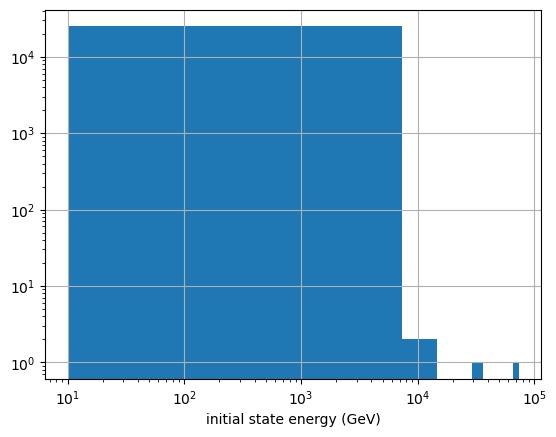

In [5]:
plt.figure()
df.initial_state_energy.hist()
plt.xscale('log')
plt.yscale('log')
plt.xlabel('initial state energy (GeV)')

In [8]:
df1 = pd.read_parquet(path  / 'pulses/pulses_806.parquet', engine='pyarrow')
df1.head()

,sensor_pos_x,sensor_pos_y,sensor_pos_z,t,string_id,is_signal,charge
event_no,,,,,,,
17241832,85.41,-52.02,154.53,0.333139,148.0,0.0,0.881995
17241832,-41.85,53.49,127.26,1.379382,68.0,0.0,0.573139
17241832,-1.63,35.26,127.26,3.019035,18.0,0.0,0.989412
17241832,-28.60,48.79,190.89,3.005323,47.0,0.0,1.164221
17241832,38.17,-44.84,109.08,2.909418,51.0,0.0,1.209050


In [7]:
df1.describe()

,sensor_pos_x,sensor_pos_y,sensor_pos_z,t,string_id,is_signal,charge
count,1.131873e+08,1.131873e+08,1.131873e+08,1.131873e+08,1.131873e+08,1.131873e+08,1.131873e+08
mean,-6.122937e-02,3.969262e-01,9.543238e+01,1.576296e+03,7.388325e+01,1.545684e-01,2.607392e+00
std,4.999561e+01,5.008825e+01,5.738569e+01,8.746304e+02,4.328564e+01,3.613814e-01,6.063396e+02
min,-9.778000e+01,-9.842000e+01,0.000000e+00,1.496130e-05,0.000000e+00,0.000000e+00,3.832601e-06
25%,-4.185000e+01,-3.933000e+01,4.545000e+01,8.116464e+02,3.600000e+01,0.000000e+00,8.384335e-01
50%,-1.250000e+00,1.380000e+00,9.090000e+01,1.623018e+03,7.400000e+01,0.000000e+00,1.011360e+00
75%,3.878000e+01,3.894000e+01,1.454400e+02,2.408156e+03,1.110000e+02,0.000000e+00,1.190755e+00
max,9.828000e+01,9.739000e+01,1.908900e+02,4.620652e+03,1.490000e+02,1.000000e+00,9.789198e+05


In [7]:
df1.sensor_pos_x.array

<NumpyExtensionArray>
[              np.float64(85.41),              np.float64(-41.85),
               np.float64(-1.63),               np.float64(-28.6),
               np.float64(38.17),                np.float64(8.54),
              np.float64(-56.11),                np.float64(38.5),
                np.float64(9.07),               np.float64(38.17),
 ...
              np.float64(-45.84),              np.float64(-23.16),
              np.float64(-23.16),              np.float64(-23.16),
              np.float64(-21.61),              np.float64(-13.75),
              np.float64(-13.34), np.float64(-13.339999999999995),
 np.float64(-13.340000000000002),                np.float64(0.88)]
Length: 113187267, dtype: float64

In [ ]:
plt.scatter(df1.sensor_pos_x, df1.sensor_pos_y)

In [8]:
import pandas as pd
# Assuming df has columns 'sensor_pos_x', 'sensor_pos_y', 'sensor_pos_z'
precision = 2 # Adjust as needed based on ORCA DOM spacing
df_rounded_coords = df1[['sensor_pos_x', 'sensor_pos_y', 'sensor_pos_z']].round(decimals=precision)
# Add string_id if available and relevant for unique identification
df_rounded_coords['string_id'] = df1['string_id']

In [10]:
df_rounded_coords.sensor_pos_x.unique()

array([ 85.41, -41.85,  -1.63, -28.6 ,  38.17,   8.54, -56.11,  38.5 ,
         9.07, -56.81, -72.44,  77.16,  63.89,  68.33, -26.71,   0.24,
        32.17,  -9.23, -97.78,  60.68, -70.93,  47.33, -69.39,  50.98,
        20.64, -23.16, -50.02, -45.84, -58.21, -73.23, -32.73,  -5.  ,
        80.01,  -4.28,  90.23,  -2.44,  24.33,  65.82, -15.12, -24.08,
       -18.27,  -1.25, -84.09, -47.6 , -23.22, -12.  ,  24.51, -19.7 ,
       -13.34,  33.31, -13.75, -27.84, -52.21,  19.43, -57.87,  80.46,
        58.88,  46.11, -82.32, -45.61, -21.61, -42.13,  66.5 ,  37.62,
       -50.04, -55.56,  91.15,   7.8 ,  76.56,  44.24, -31.46,  10.72,
        47.07,  18.81,   4.37,  16.34, -16.31,  16.61, -47.13,  58.11,
         0.88,  78.51,  -4.02,  80.15,  21.11, -31.23,  51.98, -32.59,
       -78.11,  -6.83,  38.78,  72.  ,  24.7 ,   6.64, -61.17,  65.57,
        30.02, -68.48, -69.22,  36.82,   7.89,  18.05,  50.35,  14.69,
       -74.02, -36.99, -59.78, -32.05,  32.88,   7.96, -84.06,  19.78,
      

In [11]:
unique_doms_df = df_rounded_coords.drop_duplicates().reset_index(drop=True)

In [12]:
unique_doms_df

,sensor_pos_x,sensor_pos_y,sensor_pos_z,string_id
0,85.41,-52.02,154.53,148.0
1,-41.85,53.49,127.26,68.0
2,-1.63,35.26,127.26,18.0
3,-28.60,48.79,190.89,47.0
4,38.17,-44.84,109.08,51.0
...,...,...,...,...
3295,-16.31,38.97,63.63,26.0
3296,44.24,-61.64,45.45,85.0
3297,-73.89,33.27,90.90,97.0
3298,-9.23,50.74,127.26,39.0


In [16]:
len(df_rounded_coords.string_id.unique())

150

In [17]:
3300/150

22.0

In [ ]:

# Assuming 'unique_doms_df' is your DataFrame as shown in the image

# Example: Sort by string_id (ascending), then by sensor_pos_z (descending - deeper DOMs first)
# Adjust ascending=[True, False] as per ORCA's DOM numbering convention
unique_doms_df_sorted = unique_doms_df.sort_values(
    by=['string_id', 'sensor_pos_z'],
    ascending=[True, False] # True for ascending string_id, False for descending z
).reset_index(drop=True)

# After sorting, you can assign the sensor_id based on the new sorted order
unique_doms_df_sorted['sensor_id'] = unique_doms_df_sorted.index

# Now, 'unique_doms_df_sorted' is ready to be saved as your sensor_geometry.csv
# Select and rename columns if necessary to match the expected format for SensorMapping
# e.g., sensor_pos_x -> x, sensor_pos_y -> y, sensor_pos_z -> z
final_geometry_df = unique_doms_df_sorted.rename(columns={
    'sensor_pos_x': 'x',
    'sensor_pos_y': 'y',
    'sensor_pos_z': 'z'
})

# Ensure you have the 'sensor_id', 'x', 'y', 'z' columns as a minimum
# You might want to keep 'string_id' in the final CSV for reference too.
# final_geometry_df = final_geometry_df[['sensor_id', 'x', 'y', 'z', 'string_id']] # Reorder/select columns

print("Sorted unique DOMs DataFrame head:")
print(final_geometry_df.head())


Sorted unique DOMs DataFrame head:
      x     y       z  string_id  sensor_id
0 -4.28  3.92  190.89        0.0          0
1 -4.28  3.92  181.80        0.0          1
2 -4.28  3.92  172.71        0.0          2
3 -4.28  3.92  163.62        0.0          3
4 -4.28  3.92  154.53        0.0          4


In [20]:

# Example of saving:
final_geometry_df.to_csv(path  / 'orca_sensor_geometry.csv', index=False)

In [24]:
import pandas as pd
from pathlib import Path

# Assume 'unique_doms_df' is your DataFrame after finding unique DOM positions
# from your Prometheus ORCA data. It should have columns like:
# 'sensor_pos_x', 'sensor_pos_y', 'sensor_pos_z', and 'string_id' (if available and used for sorting)

# --- Example: This is how unique_doms_df might look (replace with your actual DataFrame) ---
# data = {
# 'sensor_pos_x': [85.41, -41.85, -1.63, -28.60, 38.17],
# 'sensor_pos_y': [-52.02, 53.49, 35.26, 48.79, -44.84],
# 'sensor_pos_z': [154.53, 127.26, 127.26, 190.89, 109.08],
# 'string_id': [148.0, 68.0, 18.0, 47.0, 51.0] # Example, if you have it
# }
# unique_doms_df = pd.DataFrame(data)
# ------------------------------------------------------------------------------------------

# 1. Sort the DataFrame to establish a canonical order for DOMs.
# The index after sorting and resetting will become your 0-indexed sensor_id.
unique_doms_df_sorted = unique_doms_df.sort_values(
    by=['string_id', 'sensor_pos_z'], # Adjust sorting criteria as needed for ORCA
    ascending=[True, True]           # Adjust ascending/descending as per ORCA convention
).reset_index(drop=True)

# 2. Create the explicit 'sensor_id' column from the new 0-indexed DataFrame index.
unique_doms_df_sorted['sensor_id'] = unique_doms_df_sorted.index

# 3. Rename coordinate columns to the standard 'x', 'y', 'z'.
geometry_to_save = unique_doms_df_sorted.rename(columns={
    'sensor_pos_x': 'x',
    'sensor_pos_y': 'y',
    'sensor_pos_z': 'z'
    # 'string_id' column can be kept if you want it in the final CSV for reference
})

# 4. Select the columns for the final CSV file in the desired order: sensor_id,x,y,z
# This matches the IceCube format you provided.
output_columns = ['sensor_id', 'x', 'y', 'z']

# If you also want to include 'string_id' for reference (though not in the strict IceCube example):
# output_columns = ['sensor_id', 'x', 'y', 'z', 'string_id']

final_orca_geometry_df = geometry_to_save[output_columns]

# 5. Define the output path and save the CSV.
output_dir = Path('/groups/pheno/inar/orca_prometheus') # Your specified path
output_dir.mkdir(parents=True, exist_ok=True) # Ensure directory exists
output_csv_path = output_dir / 'orca_sensor_geometry.csv' # New name to avoid overwrite

# Save to CSV:
# - index=False: Prevents pandas from writing its current DataFrame index as another column.
# - header=True: Includes the column names (sensor_id,x,y,z) as the first line.
final_orca_geometry_df.to_csv(output_csv_path, index=False, header=True)

print(f"Sorted ORCA sensor geometry with explicit 'sensor_id' saved to: {output_csv_path}")
print("Head of the saved geometry file content:")
print(final_orca_geometry_df.head().to_string())

Sorted ORCA sensor geometry with explicit 'sensor_id' saved to: /groups/pheno/inar/orca_prometheus/orca_sensor_geometry.csv
Head of the saved geometry file content:
   sensor_id     x     y      z
0          0 -4.28  3.92   0.00
1          1 -4.28  3.92   9.09
2          2 -4.28  3.92  18.18
3          3 -4.28  3.92  27.27
4          4 -4.28  3.92  36.36
